# RF Model

In [56]:
!pip install graphviz
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.tree import plot_tree
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier, HistGradientBoostingClassifier 
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score, r2_score, classification_report
from sklearn.tree import plot_tree
from sklearn.model_selection import cross_val_score, StratifiedKFold

from sklearn.tree import export_graphviz
import graphviz


## Data Stuff

In [3]:
#BRING IN THE MOTHER
mother_file = pd.read_csv("data/one_hot_mama.csv")
#michelena test
#mother_file = pd.read_csv("data/mother_with_salaries.csv")
mother_file

# removing a ton of columns that are not helpful
# mother_file = mother_file.drop(columns=[col for col in mother_file.columns if 'waste_value_tonnes' in col])
# mother_file = mother_file.drop(columns=[col for col in mother_file.columns if 'capacity_value' in col])
# mother_file = mother_file.drop(columns=[col for col in mother_file.columns if 'waste_total_material' in col])
# mother_file = mother_file.drop(columns=[col for col in mother_file.columns if 'reserves_grade' in col])
# mother_file = mother_file.drop(columns=[col for col in mother_file.columns if 'reserves_mineral_value' in col])
# mother_file = mother_file.drop(columns=[col for col in mother_file.columns if 'reserves_commodity_value' in col])
# mother_file = mother_file.drop(columns=[col for col in mother_file.columns if 'commodities_grade' in col])
mother_file

,facility_id,primary_commodity,country,mining_salary,LOM_in_Buckets,still_operating,price_usd_tonne,2000_clean_coal_value_tonnes,2001_clean_coal_value_tonnes,2002_clean_coal_value_tonnes,...,primary_commodity_Aluminium,primary_commodity_Coal,primary_commodity_Copper,primary_commodity_Gold,primary_commodity_Iron,primary_commodity_Nickel,primary_commodity_Other (poly)-metallic,primary_commodity_Other mine,primary_commodity_Silver,primary_commodity_Zinc
0,COM00003.00,Coal,United States of America,55819.00,47.0,1.0,43.21,NaN,5356109.0,4681152.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,COM00008.00,Nickel,Spain,37500.00,11.0,0.0,16811.81,NaN,NaN,NaN,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
2,COM00009.00,Gold,Ghana,4509.60,15.0,1.0,672.01,NaN,NaN,NaN,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
3,COM00015.00,Copper,Kazakhstan,12877.81,6.0,1.0,5630.38,NaN,NaN,NaN,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,COM00016.00,Gold,Ghana,4509.60,8.0,1.0,1286.07,NaN,NaN,NaN,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
397,COM01415.00,Coal,Russian Federation,11616.07,68.0,1.0,67.27,NaN,NaN,NaN,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
398,COM01418.00,Gold,Tajikistan,2811.72,14.0,1.0,1514.58,NaN,NaN,NaN,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
399,COM01419.00,Coal,China,19604.88,12.0,1.0,70.77,NaN,NaN,NaN,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
400,COM01430.00,Gold,China,19604.88,41.0,1.0,456.56,NaN,NaN,NaN,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0


### Data Distribution of LoM

In [26]:
# info abt LoM distribution
print(mother_file["LOM_in_Buckets"].describe().round(2).to_string())
print()
 
 # quintine distribution
quintile_probs = [0.0, 0.2, 0.4, 0.6, 0.8, 1.0]
quintile_edges = mother_file["LOM_in_Buckets"].quantile(quintile_probs).tolist()
 
quintile_edges = sorted(set(quintile_edges))
 
print("Quintile cut-points (0%, 20%, 40%, 60%, 80%, 100%):")
for p, v in zip(quintile_probs, mother_file["LOM_in_Buckets"].quantile(quintile_probs)):
    print(f"  {int(p*100):>3}th percentile - {v:.1f} years")
print()
 

count    402.00
mean      30.92
std       34.49
min        1.00
25%       11.00
50%       18.00
75%       45.00
max      467.00

Quintile cut-points (0%, 20%, 40%, 60%, 80%, 100%):
    0th percentile - 1.0 years
   20th percentile - 9.0 years
   40th percentile - 14.0 years
   60th percentile - 29.0 years
   80th percentile - 49.0 years
  100th percentile - 467.0 years



In [27]:
# putting them in bins 
mother_file["LOM_quintile"] = pd.qcut(
    mother_file["LOM_in_Buckets"],
    q=5,
    labels=["Q1", "Q2", "Q3", "Q4", "Q5"],
    duplicates="drop",
)
 
print("Records per quintile bin:")
print(mother_file["LOM_quintile"].value_counts().sort_index().to_string())
print()
 
# Bin ranges for reference
print("Bin value ranges:")
for bin_name in mother_file["LOM_quintile"].cat.categories:
    subset = mother_file.loc[mother_file["LOM_quintile"] == bin_name, "LOM_in_Buckets"]
    print(f"  {bin_name:<18} → [{subset.min():.0f}, {subset.max():.0f}] yrs  (n={len(subset)})")
print()

Records per quintile bin:
LOM_quintile
Q1    84
Q2    83
Q3    78
Q4    77
Q5    80

Bin value ranges:
  Q1                 → [1, 9] yrs  (n=84)
  Q2                 → [10, 14] yrs  (n=83)
  Q3                 → [15, 29] yrs  (n=78)
  Q4                 → [30, 49] yrs  (n=77)
  Q5                 → [50, 467] yrs  (n=80)



In [28]:
mother_file

,facility_id,primary_commodity,country,mining_salary,LOM_in_Buckets,still_operating,price_usd_tonne,2000_clean_coal_value_tonnes,2001_clean_coal_value_tonnes,2002_clean_coal_value_tonnes,...,primary_commodity_Coal,primary_commodity_Copper,primary_commodity_Gold,primary_commodity_Iron,primary_commodity_Nickel,primary_commodity_Other (poly)-metallic,primary_commodity_Other mine,primary_commodity_Silver,primary_commodity_Zinc,LOM_quintile
0,COM00003.00,Coal,United States of America,55819.00,47.0,1.0,43.21,NaN,5356109.0,4681152.0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Q4
1,COM00008.00,Nickel,Spain,37500.00,11.0,0.0,16811.81,NaN,NaN,NaN,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,Q2
2,COM00009.00,Gold,Ghana,4509.60,15.0,1.0,672.01,NaN,NaN,NaN,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,Q3
3,COM00015.00,Copper,Kazakhstan,12877.81,6.0,1.0,5630.38,NaN,NaN,NaN,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Q1
4,COM00016.00,Gold,Ghana,4509.60,8.0,1.0,1286.07,NaN,NaN,NaN,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,Q1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
397,COM01415.00,Coal,Russian Federation,11616.07,68.0,1.0,67.27,NaN,NaN,NaN,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Q5
398,COM01418.00,Gold,Tajikistan,2811.72,14.0,1.0,1514.58,NaN,NaN,NaN,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,Q2
399,COM01419.00,Coal,China,19604.88,12.0,1.0,70.77,NaN,NaN,NaN,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Q2
400,COM01430.00,Gold,China,19604.88,41.0,1.0,456.56,NaN,NaN,NaN,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,Q4


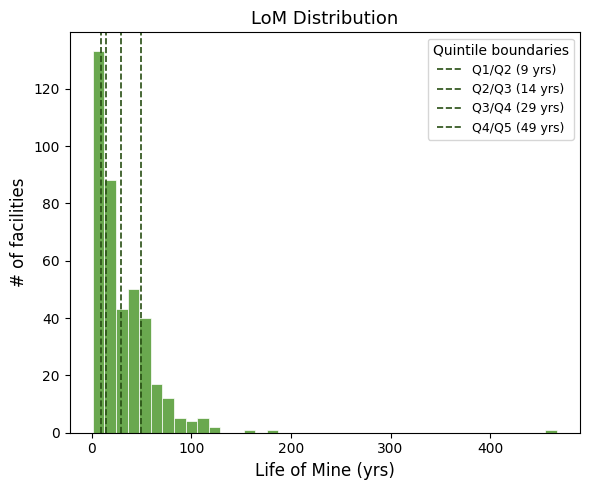

In [29]:
fig, ax = plt.subplots(figsize=(6, 5))

ax.hist(
    mother_file["LOM_in_Buckets"].dropna(),
    bins=40,
    color="#6aa84fff",
    edgecolor="white",
    linewidth=0.5,
)

# Quintile boundary lines
quintile_edges = mother_file["LOM_in_Buckets"].quantile([0.2, 0.4, 0.6, 0.8])
labels = ["Q1/Q2", "Q2/Q3", "Q3/Q4", "Q4/Q5"]
for val, lbl in zip(quintile_edges, labels):
    ax.axvline(val, color="#274e13", linestyle="--", linewidth=1.2, label=f"{lbl} ({val:.0f} yrs)")

ax.set_xlabel("Life of Mine (yrs)", fontsize=12)
ax.set_ylabel("# of facilities", fontsize=12)
ax.set_title("LoM Distribution", fontsize=13)
ax.legend(title="Quintile boundaries", fontsize=9)

plt.tight_layout()
# plt.savefig("lom_distribution.png", dpi=150, bbox_inches="tight")
plt.show()

In [30]:
# Split on facility_id
facilities = mother_file["facility_id"].unique()
train_facilities, test_facilities = train_test_split(facilities, test_size=0.2, random_state=42)

train_df = mother_file[mother_file["facility_id"].isin(train_facilities)]
test_df  = mother_file[mother_file["facility_id"].isin(test_facilities)]

print(f"Train rows : {len(train_df)} ({len(train_facilities)} facilities)")
print(f"Test rows  : {len(test_df)} ({len(test_facilities)} facilities)")

# Extract target variable
y_train = train_df["LOM_in_Buckets"]
y_test  = test_df["LOM_in_Buckets"]
drop_cols = [
    "LOM_in_Buckets",   
    "LOM_quintile",     
    "facility_id",      
    "primary_commodity",# already one-hot encoded in the dataset
    "country",          # already one-hot encoded in the dataset
]
# Drop unwanted columns (found after other data processing steps)to create feature matrices
X_train = train_df.drop(columns=drop_cols, errors="ignore").select_dtypes(include="number")
X_test  = test_df.drop(columns=drop_cols, errors="ignore").select_dtypes(include="number")

#we had a problem with infinite values accidentally :( 
X_train = X_train.replace([np.inf, -np.inf], np.nan)
X_test = X_test.replace([np.inf, -np.inf], np.nan)

# Drop rows where target variable doesn't exist
mask_train = y_train.notna()
mask_test  = y_test.notna()
X_train, y_train = X_train[mask_train], y_train[mask_train]
X_test,  y_test  = X_test[mask_test],  y_test[mask_test]

# Fill NaNs in features with training median
X_train = X_train.fillna(X_train.median())
X_test  = X_test.fillna(X_train.median())

print(f"\nFeatures used : {list(X_train.columns)}")
print(f"Train samples : {len(X_train)}")
print(f"Test samples  : {len(X_test)}")

Train rows : 321 (321 facilities)
Test rows  : 81 (81 facilities)

Features used : ['mining_salary', 'still_operating', 'price_usd_tonne', '2000_clean_coal_value_tonnes', '2001_clean_coal_value_tonnes', '2002_clean_coal_value_tonnes', '2003_clean_coal_value_tonnes', '2004_clean_coal_value_tonnes', '2005_clean_coal_value_tonnes', '2006_clean_coal_value_tonnes', '2007_clean_coal_value_tonnes', '2008_clean_coal_value_tonnes', '2009_clean_coal_value_tonnes', '2010_clean_coal_value_tonnes', '2011_clean_coal_value_tonnes', '2012_clean_coal_value_tonnes', '2013_clean_coal_value_tonnes', '2014_clean_coal_value_tonnes', '2015_clean_coal_value_tonnes', '2016_clean_coal_value_tonnes', '2017_clean_coal_value_tonnes', '2018_clean_coal_value_tonnes', '2019_clean_coal_value_tonnes', '2020_clean_coal_value_tonnes', '2000_coal_mined_value_tonnes', '2001_coal_mined_value_tonnes', '2002_coal_mined_value_tonnes', '2003_coal_mined_value_tonnes', '2004_coal_mined_value_tonnes', '2005_coal_mined_value_tonnes

In [31]:
# for the classifier
y_train_c = train_df["LOM_quintile"]
y_test_c  = test_df["LOM_quintile"]

mask_train = y_train_c.notna()
mask_test  = y_test_c.notna()
X_train, y_train_c = X_train[mask_train], y_train_c[mask_train]
X_test,  y_test_c  = X_test[mask_test],  y_test_c[mask_test]


# RandomForest Classifier

In [32]:
print(y_train_c.nunique())       # sanity check because i am going insane
print(y_train_c.value_counts())

5
LOM_quintile
Q2    69
Q1    66
Q4    65
Q3    61
Q5    60
Name: count, dtype: int64


In [33]:
clf = RandomForestClassifier(
    n_estimators=200,
    max_depth=None,
    min_samples_leaf=2,
    class_weight="balanced",   # handles any class imbalance from uneven quintiles
    random_state=42,
    n_jobs=-1,
)
clf.fit(X_train, y_train_c)

y_pred_clf = clf.predict(X_test)
print(accuracy_score(y_test_c,y_pred_clf))
print(classification_report(y_test_c, y_pred_clf))

0.41975308641975306
              precision    recall  f1-score   support

          Q1       0.52      0.78      0.62        18
          Q2       0.50      0.43      0.46        14
          Q3       0.18      0.12      0.14        17
          Q4       0.33      0.58      0.42        12
          Q5       0.50      0.25      0.33        20

    accuracy                           0.42        81
   macro avg       0.41      0.43      0.40        81
weighted avg       0.41      0.42      0.39        81



In [34]:
importances = (
    pd.Series(clf.feature_importances_, index=X_test.columns)
    .sort_values(ascending=False)
    .head(15)
)
print("Top 15 feature importances:")
for feat, imp in importances.items():
    bar = "█" * int(imp * 300)
    print(f"  {feat:<45} {imp:.4f}  {bar}")
 

Top 15 feature importances:
  price_usd_tonne                               0.0404  ████████████
  mining_salary                                 0.0199  █████
  2019_reserves_mineral_value_tonnes            0.0185  █████
  2018_minerals_ore_mined_value_tonnes          0.0157  ████
  2011_minerals_ore_mined_value_tonnes          0.0149  ████
  2011_reserves_mineral_value_tonnes            0.0143  ████
  2010_reserves_mineral_value_tonnes            0.0142  ████
  2017_reserves_mineral_value_tonnes            0.0136  ████
  2011_minerals_ore_processed_value_tonnes      0.0135  ████
  2016_reserves_mineral_value_tonnes            0.0126  ███
  2018_minerals_ore_processed_value_tonnes      0.0125  ███
  2011_clean_coal_value_tonnes                  0.0120  ███
  2018_reserves_mineral_value_tonnes            0.0120  ███
  2012_reserves_mineral_value_tonnes            0.0114  ███
  2019_minerals_ore_mined_value_tonnes          0.0110  ███


In [35]:
#cross validation
X_full = pd.concat([X_train, X_test])
y_full_c = pd.concat([y_train_c, y_test_c])

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

scores = cross_val_score(clf, X_full, y_full_c, cv=cv, scoring="accuracy")

print("Per-fold accuracy:", np.round(scores, 3))
print(f"Mean accuracy   : {scores.mean():.3f}")
print(f"Std             : {scores.std():.3f}")

Per-fold accuracy: [0.543 0.469 0.488 0.4   0.462]
Mean accuracy   : 0.472
Std             : 0.046


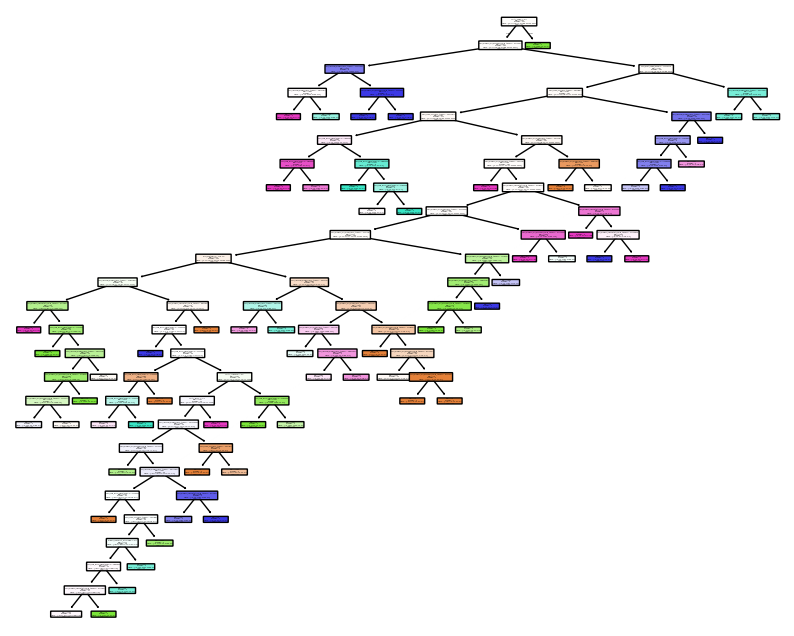

In [52]:
#let's plot this bad boy
single_tree = clf.estimators_[0]
fig, ax = plt.subplots(figsize=(10,8))

plot_tree(
    single_tree,
    feature_names=X_train.columns,
    class_names=clf.classes_,
    filled=True,
    rounded=True,
    # max_depth=3,
    ax=ax,
)

# plt.tight_layout()
# plt.savefig("lom_example_tree.png", dpi=150, bbox_inches="tight")
plt.show()

# For Loop Different Feature Combinations

In [37]:
import re
from itertools import combinations

# Group year-prefixed columns and one-hot encoded categories by their base feature name.
YEAR_PREFIX_RE = re.compile(r'^(\d{4})_(.+)$')

def base_feature_name(column_name):
    match = YEAR_PREFIX_RE.match(column_name)
    if match:
        return match.group(2)
    if column_name.startswith('country_'):
        return 'country'
    if column_name.startswith('primary_commodity_'):
        return 'primary_commodity'
    return column_name

numeric_feature_cols = [
    col for col in mother_file.select_dtypes(include='number').columns
    if col != 'LOM_in_Buckets'
]
feature_groups = {}
for col in numeric_feature_cols:
    group_name = base_feature_name(col)
    feature_groups.setdefault(group_name, []).append(col)

print(f"Found {len(feature_groups)} numeric feature groups")
for group_name, cols in sorted(feature_groups.items(), key=lambda item: (-len(item[1]), item[0])):
    print(f"{group_name}: {len(cols)} columns")

feature_group_names = sorted(feature_groups)


Found 15 numeric feature groups
country: 46 columns
clean_coal_value_tonnes: 21 columns
coal_mined_value_tonnes: 21 columns
minerals_concentrate_value_tonnes: 21 columns
minerals_ore_mined_value_tonnes: 21 columns
minerals_ore_processed_value_tonnes: 21 columns
reserves_mineral_value_tonnes: 21 columns
waste_total_material_tonnes: 19 columns
waste_value_tonnes: 19 columns
reserves_commodity_value_tonnes: 15 columns
reserves_grade_ppm: 15 columns
primary_commodity: 10 columns
mining_salary: 1 columns
price_usd_tonne: 1 columns
still_operating: 1 columns


In [38]:
import heapq

# Evaluate combinations of grouped feature sets to find the best group-level features.
# This keeps year-suffixed columns together as one group.
preferred_order = [
    'primary_commodity',
    'mining_salary',
    'price_usd_tonne',
    'still_operating',
    'country',
    'reserves_commodity_value_tonnes',
    'minerals_concentrate_value_tonnes',
    'minerals_ore_mined_value_tonnes',
    'minerals_ore_processed_value_tonnes',
    'clean_coal_value_tonnes',
    'coal_mined_value_tonnes',
]

remaining_groups = [
    g for g in feature_group_names
    if g not in preferred_order and g not in {'facility_id', 'LOM_in_Buckets'}
]

search_groups = [g for g in preferred_order if g in feature_group_names] + remaining_groups
print(f"Searching combinations over {len(search_groups)} feature groups")

best_results = []
max_results = 20
for r in range(1, min(4, len(search_groups)) + 1):
    for combo in combinations(search_groups, r):
        selected_cols = [col for group in combo for col in feature_groups[group]]
        X_train_combo = train_df[selected_cols].select_dtypes(include='number').copy()
        X_test_combo = test_df[selected_cols].select_dtypes(include='number').copy()

        X_train_combo = X_train_combo.replace([np.inf, -np.inf], np.nan)
        X_test_combo = X_test_combo.replace([np.inf, -np.inf], np.nan)

        model_combo = RandomForestRegressor(random_state=42, n_estimators=100)
        model_combo.fit(X_train_combo, y_train)
        score = r2_score(y_test, model_combo.predict(X_test_combo))

        record = {
            'feature_groups': combo,
            'num_columns': len(selected_cols),
            'r2_test': score,
        }

        if len(best_results) < max_results:
            heapq.heappush(best_results, (score, record))
        else:
            heapq.heappushpop(best_results, (score, record))

best_sorted = [record for score, record in sorted(best_results, key=lambda x: x[0], reverse=True)]
combo_df = pd.DataFrame(best_sorted)
print(combo_df.to_string(index=False))

# Save only the top results to keep the output file small.
combo_df.to_csv('data/feature_group_combo_results.csv', index=False)
print('Saved top 20 feature-group combo results to data/feature_group_combo_results.csv')


Searching combinations over 15 feature groups


KeyboardInterrupt: 

In [ ]:
# Save the best model's training and test data
best_combo = best_sorted[0]['feature_groups']
best_combo_cols = [col for group in best_combo for col in feature_groups[group]]

X_train_best = train_df[best_combo_cols].select_dtypes(include='number').copy()
X_test_best = test_df[best_combo_cols].select_dtypes(include='number').copy()

X_train_best = X_train_best.replace([np.inf, -np.inf], np.nan)
X_test_best = X_test_best.replace([np.inf, -np.inf], np.nan)

y_train_best = y_train
y_test_best = y_test

# Save to CSV files
# X_train_best.to_csv('data/best_X_train.csv', index=False)
# X_test_best.to_csv('data/best_X_test.csv', index=False)
# y_train_best.to_csv('data/best_y_train.csv', index=False)
# y_test_best.to_csv('data/best_y_test.csv', index=False)

print(f"Saved best model data:")
print(f"  Best feature groups: {best_combo}")
print(f"  X_train shape: {X_train_best.shape}")
print(f"  X_test shape: {X_test_best.shape}")
print(f"  y_train shape: {y_train_best.shape}")
print(f"  y_test shape: {y_test_best.shape}")
print(f"  Best R^2: {best_sorted[0]['r2_test']}")


# Plot For Loop Model

In [39]:
# Plot the best decision tree from the feature combination loop
best_tree_model = RandomForestRegressor(random_state=42, n_estimators=100)
best_tree_model.fit(X_train_best, y_train_best)

best_tree = best_tree_model.estimators_[0]

plt.figure(figsize=(20,10)) 
plot_tree(best_tree,
          filled=True,              
          feature_names=X_train_best.columns.tolist(),
          rounded=True)             
plt.title("Best Decision Tree from Feature Combination Loop")
plt.show()


NameError: name 'X_train_best' is not defined

In [ ]:
# we're having some trouble with X, let's see what it is -- as it turns out, some values were infinite
#print(X_train)
pd.DataFrame(X_train).to_csv('data/X_train_check.csv', index=False)

# Base Model with Random Forest

In [40]:
model = RandomForestRegressor()
model.fit(X_train, y_train)

y_pred_train = model.predict(X_train)
y_pred_test = model.predict(X_test)
# print(y_pred_train)
# print(y_pred_test)

print('R^2 train:', r2_score(y_train, y_pred_train))
print('R^2 test :', r2_score(y_test, y_pred_test))

# accuracy_train_grid = accuracy_score(y_train, y_pred_train)
# accuracy_test_grid = accuracy_score(y_test, y_pred_test)


R^2 train: 0.8547012695960857
R^2 test : 0.07013480789548754


# Random Forest with Param Grid Attribute

In [42]:
# # adapted from Pset 1 Q3 and Pset 3 Q3
param_grid = {
    'max_depth': (1, 3, 5, 10),
    'min_samples_leaf': (1, 5, 20)
    # 'criterion': (“squared_error”, “absolute_error”, “friedman_mse”, “poisson”)
}

tree = RandomForestRegressor()
grid_tree = GridSearchCV(estimator=tree,
                         param_grid=param_grid,
                         scoring='r2',
                         cv=5)

grid_tree.fit(X_train,y_train)
grid_model = grid_tree.best_estimator_

y_pred_train_grid = grid_model.predict(X_train)
y_pred_test_grid = grid_model.predict(X_test)

# accuracy_train_grid = accuracy_score(y_train, y_pred_train_grid)
# accuracy_test_grid = accuracy_score(y_test, y_pred_test_grid)

print("best accuracy", grid_tree.best_score_)
print("best params", grid_tree.best_params_)
print('Grid R^2 train:', r2_score(y_train, y_pred_train_grid))
print('Grid R^2 test :', r2_score(y_test, y_pred_test_grid))


# print(f'Train Accuracy = {accuracy_train_grid}')
# print(f'Test Accuracy = {accuracy_test_grid}')

r2_train_grid = r2_score(y_train, y_pred_train_grid)
r2_test_grid = r2_score(y_test, y_pred_test_grid)

print(f"R^2  — Train: {r2_train_grid:.4f} | Test: {r2_test_grid:.4f}")


best accuracy 0.11921778834760118
best params {'max_depth': 10, 'min_samples_leaf': 20}
Grid R^2 train: 0.1892082331043753
Grid R^2 test : 0.1362953536080126
R^2  — Train: 0.1892 | Test: 0.1363


# Plot the Random Forest with Best Param Grid Attributes (highest R^2)

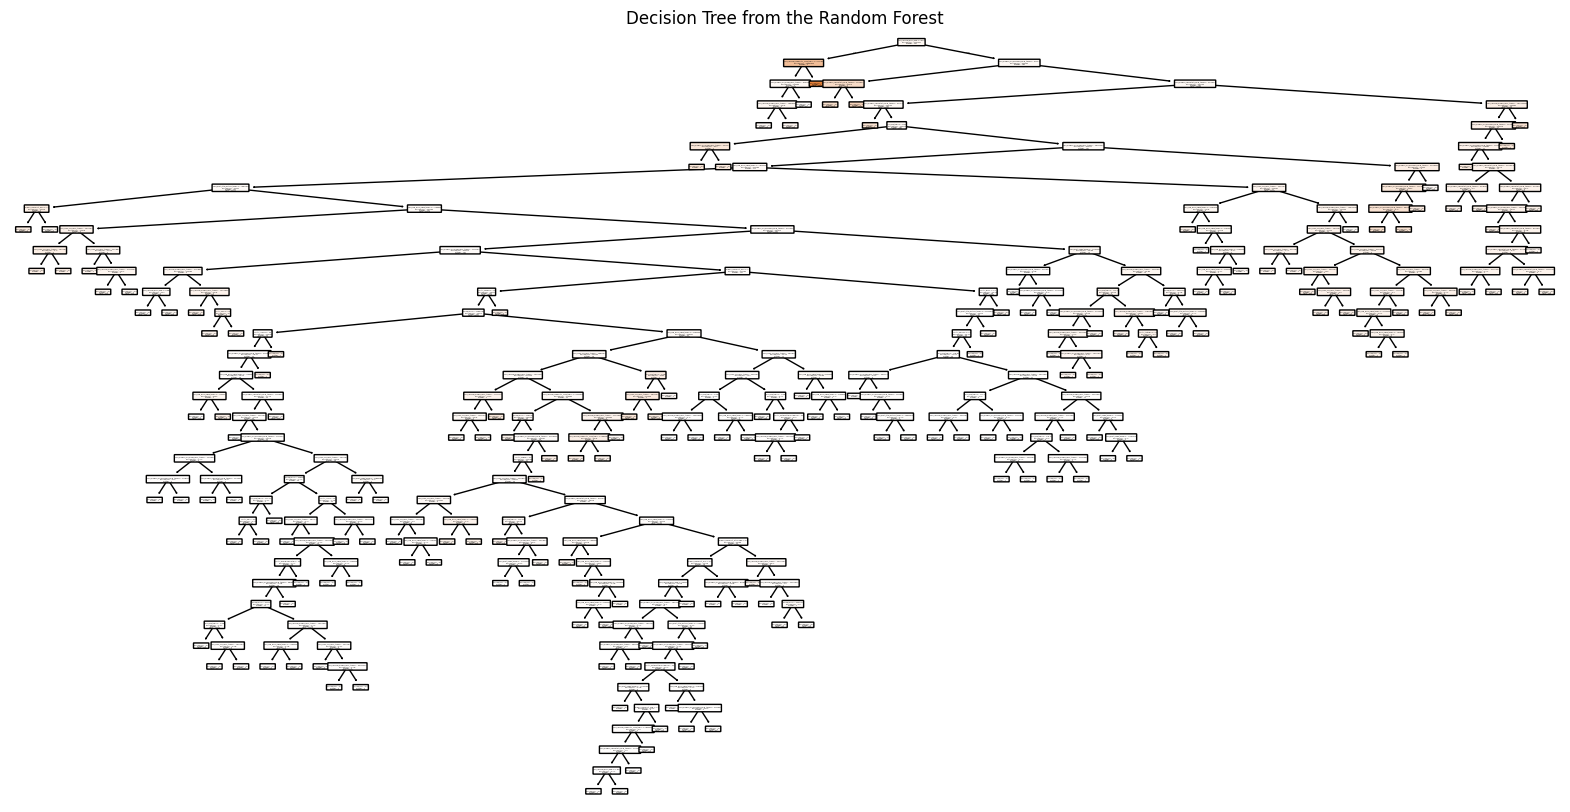

In [43]:
tree = model.estimators_[0]

plt.figure(figsize=(20,10)) 
plot_tree(tree,
          filled=True,              
          feature_names=X_train.columns.tolist(),
          rounded=True)             # make things pretty
plt.title("Decision Tree from the Random Forest")
plt.show()

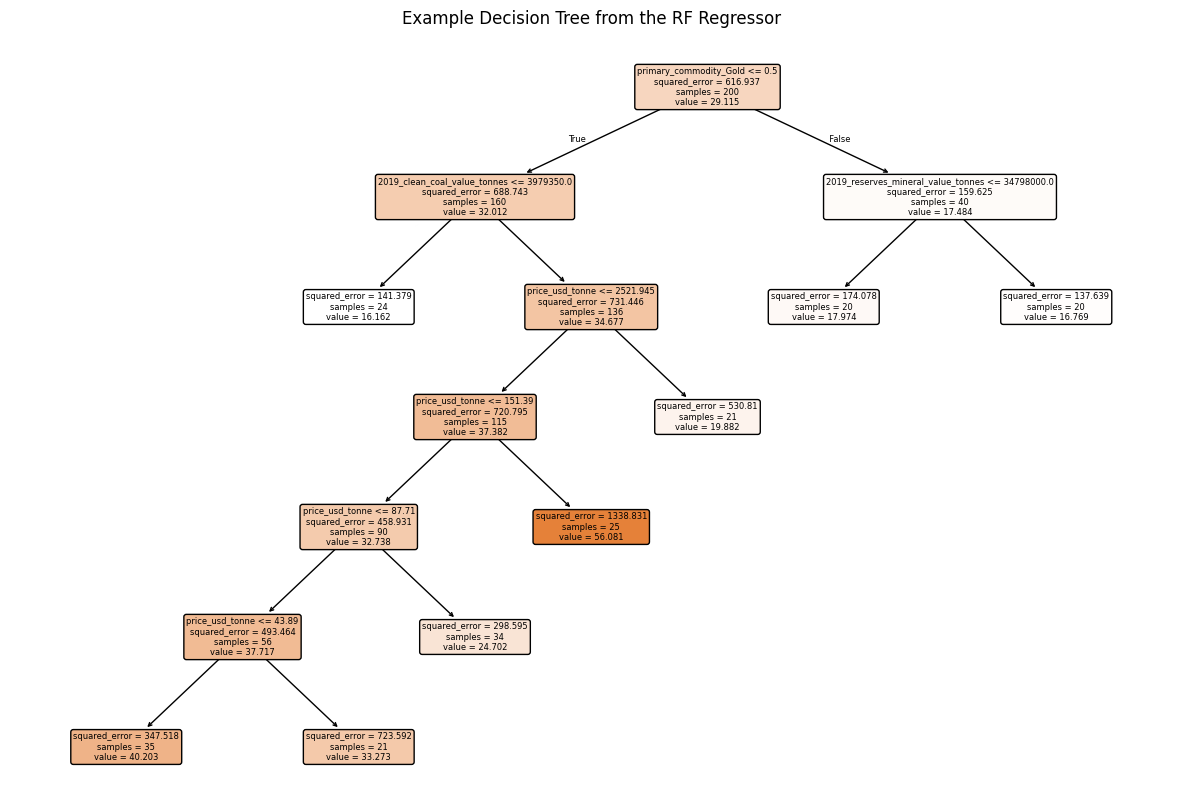

In [49]:
grid_tree = grid_model.estimators_[0]

plt.figure(figsize=(15,10)) 
plot_tree(grid_tree,
          filled=True,              
          feature_names=X_train.columns.tolist(),
          rounded=True)             
plt.title("Example Decision Tree from the RF Regressor")
plt.show()

## Gradient Boosting

In [ ]:
# ── 1. Define model ────────────────────────────────────────────────────────────
gb_clf = HistGradientBoostingClassifier(random_state=42) # normal grad boosting had too many NaNs and couldn't deal with it :( 

# ── 2. Hyperparameter grid ─────────────────────────────────────────────────────
param_grid = {
    "max_iter":        [100, 200, 300],   
    "max_depth":       [3, 5, 7],
    "learning_rate":   [0.01, 0.05, 0.1],
    "max_leaf_nodes":  [31, 63],          
    "min_samples_leaf":[1, 2, 5],
}

# ── 3. Grid search with stratified CV ─────────────────────────────────────────
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

gb_grid = GridSearchCV(
    gb_clf,
    param_grid,
    cv=cv,
    scoring="accuracy",
    n_jobs=-1,
    verbose=1,
)

gb_grid.fit(X_train, y_train_c)

# ── 4. Evaluate ────────────────────────────────────────────────────────────────
print(f"Best params   : {gb_grid.best_params_}")
print(f"Best CV score : {gb_grid.best_score_:.3f}")
print()

y_pred_gb = gb_grid.predict(X_test)
print(f"Test accuracy : {accuracy_score(y_test_c, y_pred_gb):.3f}")
print()
print("Classification report:")
print(classification_report(y_test_c, y_pred_gb, target_names=gb_grid.classes_))


Fitting 5 folds for each of 162 candidates, totalling 810 fits
Best params   : {'learning_rate': 0.01, 'max_depth': 7, 'max_iter': 200, 'max_leaf_nodes': 31, 'min_samples_leaf': 2}
Best CV score : 0.470

Test accuracy : 0.395

Classification report:
              precision    recall  f1-score   support

          Q1       0.48      0.78      0.60        18
          Q2       0.50      0.36      0.42        14
          Q3       0.17      0.12      0.14        17
          Q4       0.35      0.50      0.41        12
          Q5       0.38      0.25      0.30        20

    accuracy                           0.40        81
   macro avg       0.38      0.40      0.37        81
weighted avg       0.38      0.40      0.37        81



ValueError: Classification metrics can't handle a mix of multiclass and continuous targets

In [59]:
# ── 5. Compare against your RF ────────────────────────────────────────────────
y_pred_rf = clf.predict(X_test)
print("=" * 40)
print(f"RF accuracy : {accuracy_score(y_test_c, y_pred_rf):.3f}")
print(f"GB accuracy : {accuracy_score(y_test_c, y_pred_gb):.3f}")

RF accuracy : 0.420
GB accuracy : 0.395


# Begin Evaluations